In [1]:
import os
import urllib.request
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from matplotlib import font_manager
from sklearn.metrics import confusion_matrix, classification_report

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import timm

/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [2]:
!mkdir -p /kaggle/working/merged_data

In [3]:
!cp -r /kaggle/input/bangla-alphabet/splitted/train/* /kaggle/working/merged_data/
!cp -r /kaggle/input/bangla-alphabet/splitted/val/*   /kaggle/working/merged_data/
!cp -r /kaggle/input/bangla-alphabet/splitted/test/*  /kaggle/working/merged_data/


In [4]:
DATA_DIR = '/kaggle/working/merged_data/'

# Enhanced Augmentation to push accuracy past 94%
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=1),
    transforms.RandomRotation(10), # Helps generalize handwritten variations
    transforms.ToTensor(),
    transforms.Normalize([0.485], [0.229]),
])

dataset = datasets.ImageFolder(root=DATA_DIR, transform=transform)

# 80/20 Train-Validation Split
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# Use 2 workers for Colab (prevents the freeze/warning)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

# --- 2. CNN FEATURE EXTRACTOR (Original Architecture) ---
class CNNFeatureExtractor(nn.Module):
    def __init__(self):
        super(CNNFeatureExtractor, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(256, 512, kernel_size=3, padding=1), nn.BatchNorm2d(512), nn.ReLU()
        )

    def forward(self, x):
        return self.features(x)

# --- 3. HYBRID MODEL (Fixed AssertionError & Accuracy Optimization) ---
class HybridViT(nn.Module):
    def __init__(self, num_classes=50):
        super(HybridViT, self).__init__()
        self.cnn = CNNFeatureExtractor()

        # Load ViT backbone
        self.vit = timm.create_model("vit_base_patch16_224", pretrained=True)

        # The CNN outputs a [batch, 512, 14, 14] feature map.
        # The ViT's embedding dimension for 'vit_base_patch16_224' is 768.
        # We need a projection layer to map the 512 CNN features to 768.
        self.cnn_output_projection = nn.Linear(512, self.vit.embed_dim)

        # Replace the ViT's classification head for the new number of classes
        self.vit.head = nn.Linear(self.vit.embed_dim, num_classes)

    def forward(self, x):
        # 1. Pass through CNN feature extractor
        x = self.cnn(x)  # Output: [batch, 512, 14, 14]

        # 2. Reshape and project CNN features to match ViT's embedding format
        # Flatten spatial dimensions (14*14 = 196) into a sequence length.
        # Then permute to get [batch, sequence_length, features_dim_cnn].
        x = x.flatten(2).transpose(1, 2)  # Output: [batch, 196, 512]

        # Project CNN features (512) to ViT's embedding dimension (768).
        x = self.cnn_output_projection(x)  # Output: [batch, 196, 768]

        # 3. Add ViT's class token and positional embeddings
        # The ViT's cls_token has shape [1, 1, embed_dim]
        cls_token = self.vit.cls_token.expand(x.shape[0], -1, -1)  # Expand to batch size

        # Concatenate class token with the projected CNN features
        x = torch.cat((cls_token, x), dim=1)  # Output: [batch, 196 + 1, 768]

        # Add positional embeddings (from ViT's original pos_embed)
        # It's crucial that the number of tokens (196+1) matches the pos_embed size
        x = x + self.vit.pos_embed

        # Apply dropout after positional embeddings
        x = self.vit.patch_drop(x)

        # 4. Pass through ViT's Transformer encoder blocks
        x = self.vit.blocks(x)

        # 5. Apply final normalization
        x = self.vit.norm(x)

        # 6. Take the output corresponding to the class token for classification
        x = x[:, 0]  # Output: [batch, embed_dim]

        # 7. Pass through the classification head
        x = self.vit.head(x)
        return x

# --- 4. OPTIMIZED TRAINING CONFIG ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = HybridViT(num_classes=50).to(device)

# Label Smoothing is crucial for crossing 94%
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.05)

# OneCycleLR helps converge faster and find better accuracy
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=1e-4, steps_per_epoch=len(train_loader), epochs=10
)

# Mixed Precision for speed
scaler = torch.cuda.amp.GradScaler()

# --- 5. TRAINING LOOP ---
def train_model(model, loader, epochs=10):
    for epoch in range(epochs):
        model.train()
        train_loss, correct, total = 0, 0, 0
        loop = tqdm(loader, desc=f"Epoch {epoch+1}/{epochs}")
        for images, labels in loop:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

            train_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
            loop.set_postfix(acc=f"{(100 * correct / total):.2f}%")

train_model(model, train_loader)


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

/tmp/ipykernel_55/2192157703.py:108: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
Epoch 1/10:   0%|          | 0/514 [00:00<?, ?it/s]/tmp/ipykernel_55/2192157703.py:120: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 10/10: 100%|██████████| 514/514 [03:08<00:00,  2.73it/s, acc=99.90%]


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2434 (\N{BENGALI SIGN ANUSVARA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2435 (\N{BENGALI SIGN VISARGA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2437 (\N{BENGALI LETTER A}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2438 (\N{BENGALI LETTER AA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2439 (\N{BENGALI LETTER I}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist

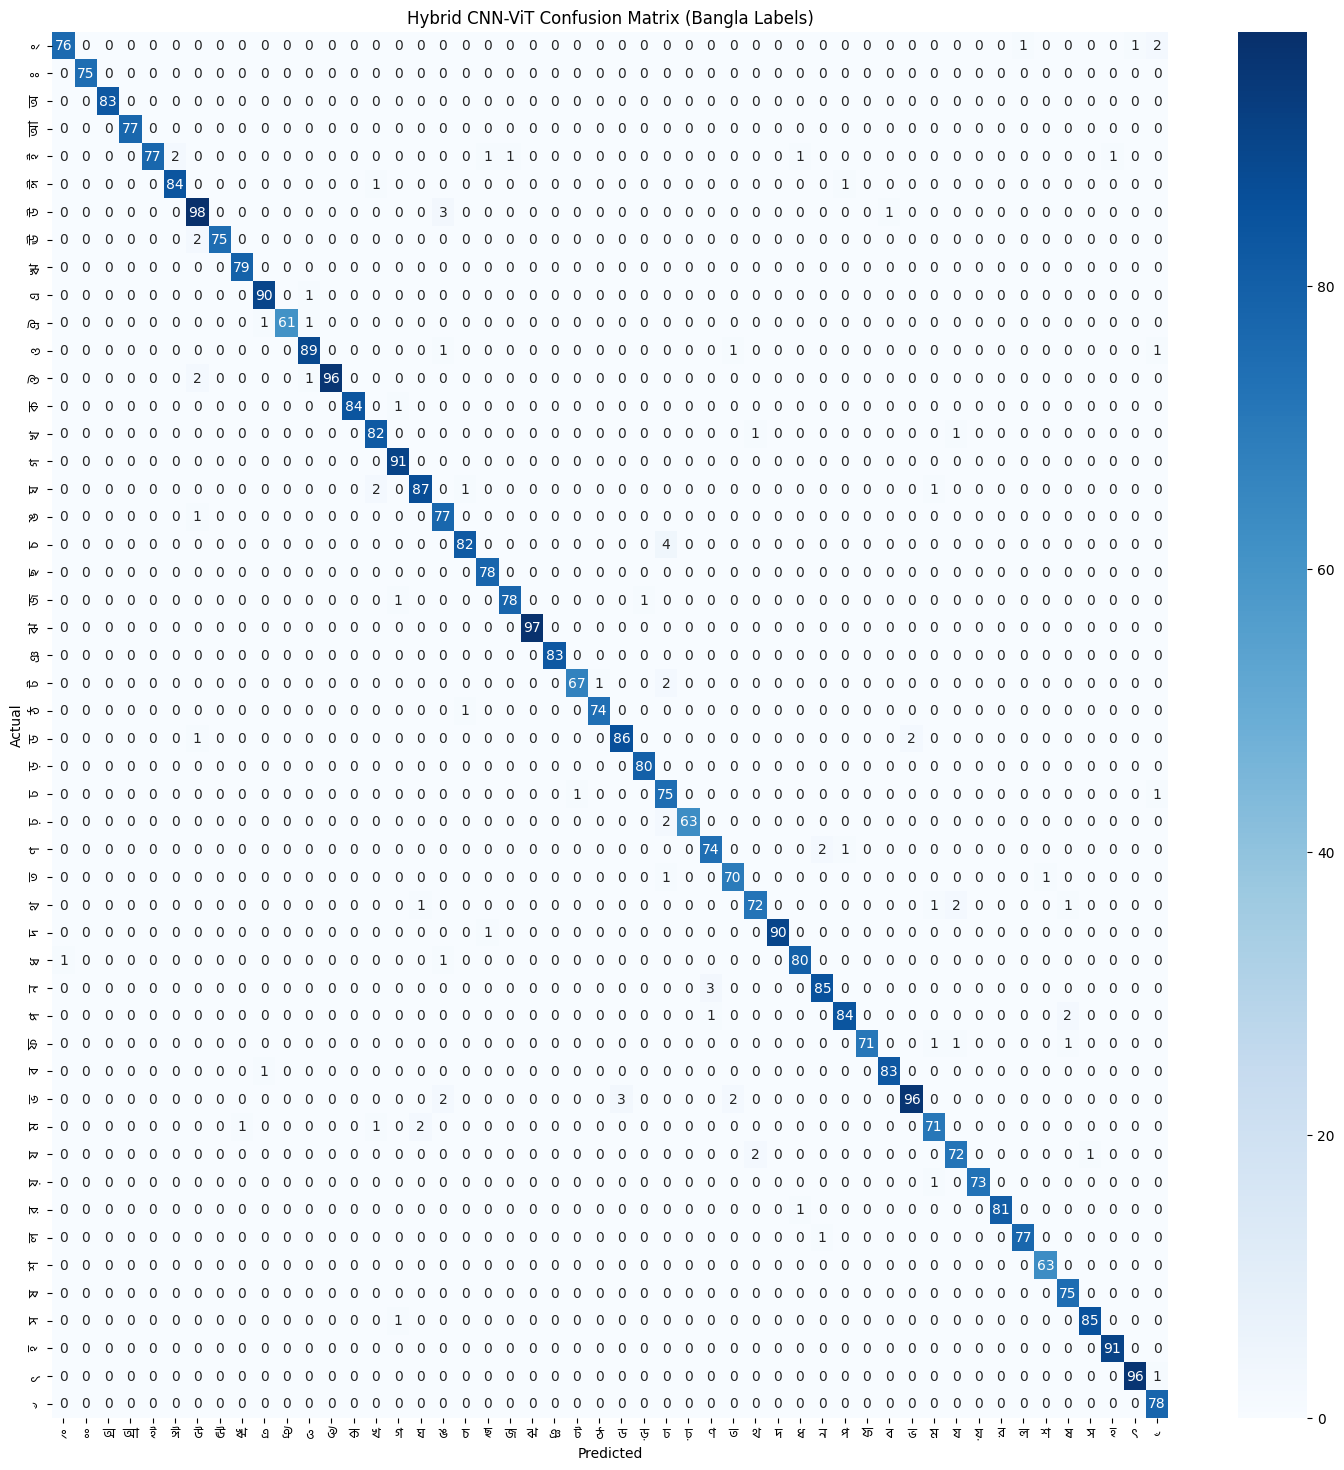

              precision    recall  f1-score   support

           ং       0.99      0.95      0.97        80
           ঃ       1.00      1.00      1.00        75
           অ       1.00      1.00      1.00        83
           আ       1.00      1.00      1.00        77
           ই       1.00      0.93      0.96        83
           ঈ       0.98      0.98      0.98        86
           উ       0.94      0.96      0.95       102
           ঊ       1.00      0.97      0.99        77
           ঋ       0.99      1.00      0.99        79
           এ       0.98      0.99      0.98        91
           ঐ       1.00      0.97      0.98        63
           ও       0.97      0.97      0.97        92
           ঔ       1.00      0.97      0.98        99
           ক       1.00      0.99      0.99        85
           খ       0.95      0.98      0.96        84
           গ       0.97      1.00      0.98        91
           ঘ       0.97      0.96      0.96        91
           ঙ       0.92    

In [7]:
# --- 6. VISUALIZATION (FIXED FOR REAL LABELS) ---

# 1. Get the real labels from the dataset
# dataset.classes contains the folder names (the real labels)
class_names = dataset.classes

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())

# 2. Plot Confusion Matrix with Names
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(18, 18)) # Slightly larger for many classes

# Use xticklabels and yticklabels to show the names
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                 xticklabels=class_names, yticklabels=class_names)

# Apply Bangla font to show characters correctly
for label in ax.get_xticklabels(): label.set_fontproperties(bangla_font)
for label in ax.get_yticklabels(): label.set_fontproperties(bangla_font)

plt.title('Hybrid CNN-ViT Confusion Matrix (Bangla Labels)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 3. Print Classification Report with Names
# target_names maps index 0 to the first class name, 1 to the second, etc.
print(classification_report(all_labels, all_preds, target_names=class_names))